In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

from gsmo.hist_features_uni import extract_embeddings
from gsmo.utils import *
from gsmo import GSMO, GSMOConfig
from PIL import Image
import pandas as pd
import numpy as np
import scanpy as sc
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
Image.MAX_IMAGE_PIXELS = None
Image.MAX_IMAGE_PIXELS = None
import torch
import random

seed=100
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    device = 'cuda'
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print("CUDA is available. GPU:", torch.cuda.get_device_name(0))
else:
    device = 'cpu'
    print("CUDA is not available. Using CPU.")


CUDA is available. GPU: NVIDIA GeForce RTX 3090


In [2]:
import os
os.chdir('data/spatial-mux-seq/E13_20um')

In [ ]:
rna = sc.read('scRNA.h5ad')
spatial_coords = rna.obs[['x', 'y']].copy()
spatial_coords = spatial_coords.values
rna_feat = preprocess(rna, modality='rna')

H3K27me3 = sc.read('H3K27me3_seurat_object.h5ad')
H3K27me3_feat = H3K27me3.obsm['X_lsi']
# preprocess(H3K27me3, modality='histone')

H3K4me3 = sc.read('H3K4me3_seurat_object.h5ad')
H3K4me3_feat = H3K4me3.obsm['X_lsi']
# preprocess(H3K4me3, modality='histone')


/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/scanpy/preprocessing/_scale.py:317: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


"#Load data and perform necessary preprocessing\nrna = sc.read('scRNA.h5ad')\nprint(rna)\n\nspatial_coords = rna.obs[['x', 'y']].copy()\nspatial_coords = spatial_coords.values\n# print(spatial_coords.shape)\n\nrna.var_names_make_unique()\nrna = preprocess(rna,modality='rna')\n\natac = sc.read('atac_seurat_object.h5ad')\nprint(atac)\natac.var_names_make_unique()\natac = preprocess(atac,modality='atac')\n\nprotein = sc.read('scProtein.h5ad')\nprint(protein)\nprotein.var_names_make_unique()\nprotein = preprocess(protein,modality='protein')\n\nH3K27me3 = sc.read('H3K27me3_seurat_object.h5ad')\nprint(H3K27me3)\nH3K27me3.var_names_make_unique()\nH3K27me3 = preprocess(H3K27me3,modality='H3K27me3')\n\nH3K27ac = sc.read('H3K27ac_seurat_object.h5ad')\nprint(H3K27ac)\nH3K27ac.var_names_make_unique()\nH3K27ac = preprocess(H3K27ac,modality='H3K27ac')"

In [4]:
print(rna_feat.shape)
print(H3K27me3_feat.shape)
print(H3K4me3_feat.shape)

(2224, 2879)
(2224, 50)
(2224, 50)


In [ ]:
#if using a subset of modality-specific terms, the "ind_views" parameter should be a list with values entries to the indices of the modalities to be included, e.g.,  ind_views=[0,2] if including RNA and image features
#if using a subset of interaction terms, the "combs" parameter should be a list of tuples with entries to the indices of the modalities for each interaction, e.g. combs = [(0,1),(0,2)] if including the RNA-protein and RNA-image interaction terms
features_dict = {
        'rna': rna_feat,        # RNA
        'h3k27me3': H3K27me3_feat,    # H3K27me3 
        'h3k4me3': H3K4me3_feat    # H3K27ac 
    }

initial_weights = [1.0, 1.0, 1.0] 

cfg = GSMOConfig

model = GSMO(features_dict, spatial_coords=spatial_coords, device=device, cfg=cfg,
            trainable_weights=True, initial_weights=initial_weights)

model.load_state_dict(torch.load("best_model_3m.pth"))

/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


<All keys matched successfully>

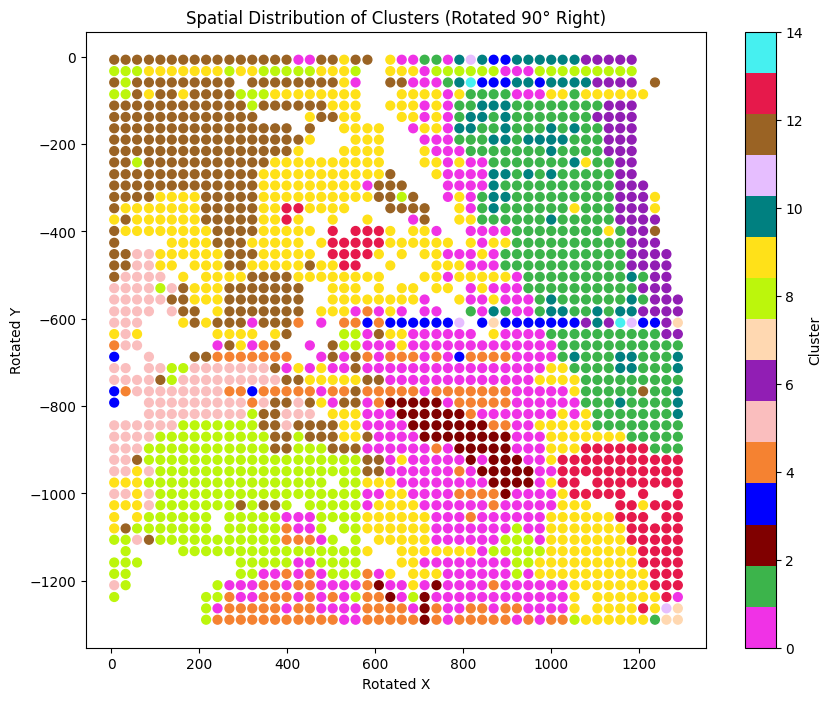

In [ ]:

from matplotlib.colors import ListedColormap

plot_color = ['#f032e6','#3cb44b', '#800000', '#0000ff',  '#f58231', '#fabebe', '#911eb4', '#ffd8b1', 
              '#bcf60c', '#ffe119', '#008080', '#e6beff', '#9a6324', '#e6194b', '#46f0f0', '#aaffc3', '#808000', 
              '#000075', '#000000', '#808080', '#ffffff', '#fffac8', '#D1D1D1']   # '#911eb4'

rna = sc.read('scRNA.h5ad')

# print(rna.obs)

assert 'x' in rna.obs.columns and 'y' in rna.obs.columns

rna_locs = rna.obs[['x', 'y']].copy()


# rna_locs = rna.obsm['spatial'] 
assert rna_locs is not None and rna_locs.shape[1] == 2

clusters = model.cluster_kmeans(n_clusters=15)

rna_locs_df = pd.DataFrame(rna_locs, columns=['x', 'y'])  
rna_locs_df['cluster'] = clusters  

num_clusters = len(np.unique(clusters))


if num_clusters > len(plot_color):
    raise ValueError(f"cluster number {num_clusters} is more than {len(plot_color)}。")

cmap = ListedColormap(plot_color[:num_clusters])
rna_locs_df['x_rot'] = rna_locs_df['y']
rna_locs_df['y_rot'] = -rna_locs_df['x']

plt.figure(figsize=(10, 8))
scatter = plt.scatter(rna_locs_df['x_rot'], rna_locs_df['y_rot'], c=rna_locs_df['cluster'], cmap=cmap, s=40)
plt.colorbar(scatter, label="Cluster")
plt.title("Spatial Distribution of Clusters (Rotated 90° Right)")
plt.xlabel('Rotated X')
plt.ylabel('Rotated Y')
# plt.gca().invert_yaxis() 
plt.show()



In [ ]:
import skimage
from sklearn.metrics import pairwise_distances
import numpy as np
from tqdm import tqdm

def compute_jaccard_similarity(Z_m, Z_e, k=50):
    dist_m = pairwise_distances(Z_m)
    dist_e = pairwise_distances(Z_e)
    
    n = Z_m.shape[0]
    jaccard_scores = []

    for i in tqdm(range(n), desc="Calculating Jaccard similarities"):
        neighbors_m = set(np.argsort(dist_m[i])[1:k+1])  # exclude self
        neighbors_e = set(np.argsort(dist_e[i])[1:k+1])
        intersection = len(neighbors_m & neighbors_e)
        union = len(neighbors_m | neighbors_e)
        jaccard = intersection / union if union > 0 else 0.0
        jaccard_scores.append(jaccard)

    return np.array(jaccard_scores), np.mean(jaccard_scores)


import squidpy as sq
import scanpy as sc
import pandas as pd
import numpy as np

def compute_morans_I(labels, spatial_coords, label_name="cluster_label"):

    adata = sc.AnnData(X=np.zeros((len(labels), 1)))  # dummy
    adata.obs[label_name] = pd.Categorical([str(x) for x in labels])
    adata.obsm['spatial'] = spatial_coords.astype(float)

    sq.gr.spatial_neighbors(adata, coord_type="generic", n_neighs=6)

    sq.gr.spatial_autocorr(adata, mode="moran", genes=label_name, attr="obs")

    moran_result = adata.uns["moranI"].loc[label_name, "I"]
    return moran_result


fused_embeddings = model.get_embeddings()


# 1. Jaccard
jaccard_all, jaccard_mean = compute_jaccard_similarity(rna_feat, fused_embeddings, k=50)
print(f"Mean Jaccard RNA Similarity: {jaccard_mean:.4f}")

jaccard_all, jaccard_mean = compute_jaccard_similarity(H3K27me3_feat, fused_embeddings, k=50)
print(f"Mean Jaccard H3K27me3 Similarity: {jaccard_mean:.4f}")

jaccard_all, jaccard_mean = compute_jaccard_similarity(H3K4me3_feat, fused_embeddings, k=50)
print(f"Mean Jaccard H3K4me3 Similarity: {jaccard_mean:.4f}")

cluster_labels = model.cluster_kmeans(n_clusters=15)
morans_I = compute_morans_I(cluster_labels, spatial_coords)
print(f"Moran's I score: {morans_I:.4f}")

/home/user2/anaconda3/envs/UNI/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
Calculating Jaccard similarities: 100%|██████████| 2224/2224 [00:00<00:00, 6447.61it/s]


Mean Jaccard RNA Similarity: 0.0498


Calculating Jaccard similarities: 100%|██████████| 2224/2224 [00:00<00:00, 6394.17it/s]


Mean Jaccard H3K27me3 Similarity: 0.0907


Calculating Jaccard similarities: 100%|██████████| 2224/2224 [00:00<00:00, 6399.61it/s]


Mean Jaccard H3K4me3 Similarity: 0.0696
Moran's I score: 0.6617


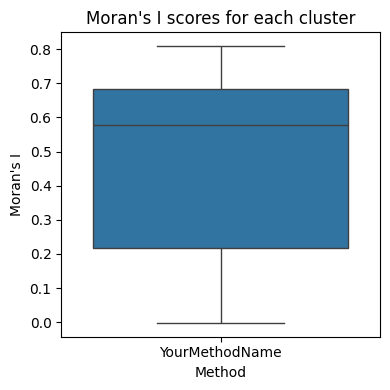

   cluster   moran_I          method
0        0  0.480938  YourMethodName
1        1  0.708244  YourMethodName
2        2  0.641967  YourMethodName
3        3  0.186031  YourMethodName
4        4  0.385205  YourMethodName
5        5  0.660874  YourMethodName
6        6  0.702972  YourMethodName
7        7  0.198423  YourMethodName
8        8  0.709888  YourMethodName
9        9  0.578200  YourMethodName
10      10  0.238445  YourMethodName
11      11 -0.001952  YourMethodName
12      12  0.628040  YourMethodName
13      13  0.808692  YourMethodName
14      14 -0.000900  YourMethodName


In [ ]:
import squidpy as sq
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def compute_morans_I_per_method(labels, spatial_coords, method_name="MethodA"):

    adata = sc.AnnData(X=np.zeros((len(labels), 1)))
    adata.obs["cluster_label"] = pd.Categorical([str(x) for x in labels])
    adata.obsm['spatial'] = spatial_coords.astype(float)

    sq.gr.spatial_neighbors(adata, coord_type="generic", n_neighs=6)

    moran_scores = []
    unique_labels = np.unique(labels)

    for label in unique_labels:
        binary_vector = (labels == label).astype(int)
        adata.obs["tmp_binary"] = binary_vector

        sq.gr.spatial_autocorr(adata, mode="moran", genes="tmp_binary", attr="obs")
        I_score = adata.uns["moranI"].loc["tmp_binary", "I"]
        moran_scores.append({
            "cluster": str(label),
            "moran_I": I_score,
            "method": method_name
        })

    df_moran = pd.DataFrame(moran_scores)

    plt.figure(figsize=(4, 4))
    sns.boxplot(data=df_moran, x="method", y="moran_I")
    plt.title("Moran's I scores for each cluster")
    plt.ylabel("Moran's I")
    plt.xlabel("Method")
    plt.tight_layout()
    plt.show()

    return df_moran

morans_I_df = compute_morans_I_per_method(cluster_labels, spatial_coords, method_name="YourMethodName")
print(morans_I_df)
